# Optical Properties for g-BC3

The correlation between optical properties and energy across a multitude of vacant energy bands.

## Optical Properties in specific number of vacant energy bands

* NBANDS = 128

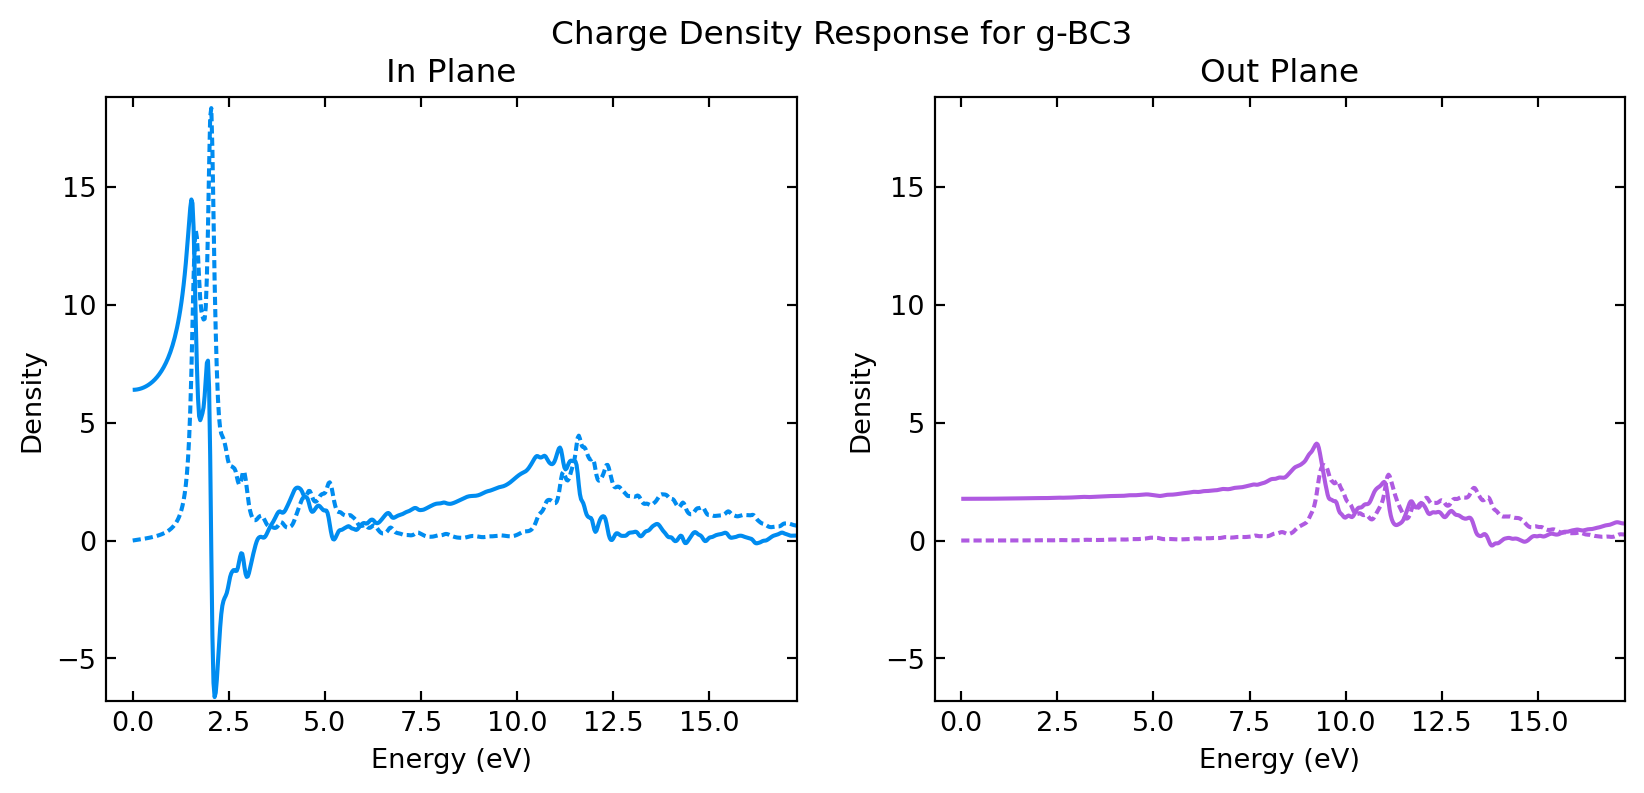

In [1]:
#### Ploting for Charge Density Response in specific NBANDS

### Import the necessary packages and data for plotting

import matplotlib.pyplot as plt
import numpy as np
from optical_properties import extract_optical_properties

def set_plot_style(ax):
    params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", 
              "axes.titlesize": 12, "axes.labelsize": 10, "figure.facecolor": "w"}
    plt.rcParams.update(params)
    ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

def get_plot_range(opt_data):
    max_value = np.max([opt_data[f"density_{ax}_{comp}"] for ax in ["xx", "yy", "zz"] for comp in ["imag", "real"]])
    min_value = np.min([opt_data[f"density_{ax}_{comp}"] for ax in ["xx", "yy", "zz"] for comp in ["imag", "real"]])
    x_range = np.max([opt_data["density_energy_real"], opt_data["density_energy_imag"],])
    x_left = -x_range * 0.01
    x_right = x_range * 0.25
    return min_value * 1.025, max_value * 1.025, x_left, x_right

def plot_density(ax, energy_data_real, density_data_real, energy_data_imag, density_data_imag, color, linewidth, label, title):
    set_plot_style(ax)
    lines_real = ax.plot(energy_data_real, density_data_real, c=color, linewidth=linewidth, label=label + " (real)")
    lines_real[0].set_dashes([2, 0])
    lines_imag = ax.plot(energy_data_imag, density_data_imag, c=color, linewidth=linewidth, label=label + " (imag)")
    lines_imag[0].set_dashes([2, 1])
    ax.set_title(title)

def plot_charge_density_response(opt_data):
    y_range_min, y_range_max, x_range_left, x_range_right = get_plot_range(opt_data)
    fig, axs = plt.subplots(1, 2, dpi=196, figsize=(10, 4))
    fig.suptitle("Charge Density Response for g-BC3")
    axs[0].set_xlabel(r"Energy (eV)"); axs[0].set_ylabel(r"Density")
    axs[1].set_xlabel(r"Energy (eV)"); axs[1].set_ylabel(r"Density")

    plot_density(axs[0], opt_data["density_energy_real"], opt_data["density_xx_real"], opt_data["density_energy_imag"], opt_data["density_xx_imag"], "#008CF0", 1.5, "Part in plane", "In Plane")
    plot_density(axs[1], opt_data["density_energy_real"], opt_data["density_zz_real"], opt_data["density_energy_imag"], opt_data["density_zz_imag"], "#AF5AE1", 1.5, "Part out plane", "Out Plane")

    for ax in axs:
        ax.set_ylim(y_range_min, y_range_max)
        ax.set_xlim(x_range_left, x_range_right)
    plt.show()

opt_128 = extract_optical_properties("6_Optical_properties_gamma_Nbands_128/vasprun.xml")
plot_charge_density_response(opt_128)